# Genre Classifier
Trains **Logistic Regression**, **SVM**, **Random Forest**, **Naïve Bayes**, **KNN**, and **XGBoost** models to classify book genre from
100-word text partitions.

**Inputs required (run the other notebooks first):**
- `partitions.csv` — from `book_partitioner.ipynb`
- `vocabulary.csv` — from `book_ngram_analysis.ipynb`

**Outputs:** accuracy scores, classification reports, and confusion matrices.

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
import joblib

## Configuration

In [2]:
PARTITIONS_CSV = "partitions.csv"   # output of book_partitioner.ipynb
VOCABULARY_CSV = "vocabulary.csv"   # output of book_ngram_analysis.ipynb

TEST_SIZE      = 0.2    # 80/20 train-test split
RANDOM_STATE   = 42
CV_FOLDS       = 5      # stratified k-fold cross-validation

# Genres in a consistent display order
GENRES = ["autobiography", "fantasy", "horror", "romance", "sci-fi"]


## Load Data

In [3]:
partitions = pd.read_csv(PARTITIONS_CSV)
vocabulary  = pd.read_csv(VOCABULARY_CSV)["word"].tolist()

print(f"Partitions loaded : {len(partitions):,} rows")
print(f"Vocabulary size   : {len(vocabulary):,} words")
print(f"\nGenre distribution:")
print(partitions['genre'].value_counts().to_string())
partitions.head(3)


Partitions loaded : 1,000 rows
Vocabulary size   : 1,270 words

Genre distribution:
genre
fantasy          200
romance          200
sci-fi           200
horror           200
autobiography    200


,partition_id,book,genre,start_token,text,word_count
0,TheWonderfulWizardOfOz_partition_a,TheWonderfulWizardOfOz,fantasy,7296,"at the tin legs, which hurt his teeth. “Did yo...",100
1,TheWonderfulWizardOfOz_partition_b,TheWonderfulWizardOfOz,fantasy,1639,her eyes growing bigger and bigger at the wond...,100
2,TheWonderfulWizardOfOz_partition_c,TheWonderfulWizardOfOz,fantasy,18024,him your message. He said he will grant you an...,100


## Build Feature Matrix
We use **TF-IDF** restricted to the vocabulary derived from the n-gram analysis.
This ensures the features are exactly the top-100 unigrams we identified per book,
de-duplicated into a shared vocabulary.

In [4]:
X_text = partitions["text"].tolist()
y      = partitions["genre"].tolist()

# TF-IDF restricted to our pre-built vocabulary
vectorizer = TfidfVectorizer(
    vocabulary    = vocabulary,
    sublinear_tf  = True,      # apply log(1+tf) — reduces impact of very frequent words
    strip_accents = 'unicode',
    analyzer      = 'word',
    token_pattern = r'[a-z]+',
    lowercase     = True,
)

X = vectorizer.fit_transform(X_text)
print(f"Feature matrix shape: {X.shape}")
print(f"  {X.shape[0]} partitions  ×  {X.shape[1]} vocabulary features")


Feature matrix shape: (1000, 1270)
  1000 partitions  ×  1270 vocabulary features


## Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,      # preserve genre proportions in both splits
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")


Training samples : 800
Test samples     : 200


## Model 1 — Logistic Regression

In [6]:
lr = LogisticRegression(
    max_iter      = 1000,
    random_state  = RANDOM_STATE,
    C             = 1.0,
    solver        = 'lbfgs',
    multi_class   = 'multinomial',
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=" * 50)
print(" Logistic Regression — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print(classification_report(y_test, y_pred_lr, target_names=GENRES))


 Logistic Regression — Test Set
Accuracy: 0.9550

               precision    recall  f1-score   support

autobiography       0.86      0.95      0.90        40
      fantasy       0.98      1.00      0.99        40
       horror       1.00      0.93      0.96        40
      romance       0.95      0.90      0.92        40
       sci-fi       1.00      1.00      1.00        40

     accuracy                           0.95       200
    macro avg       0.96      0.96      0.96       200
 weighted avg       0.96      0.95      0.96       200



## Model 2 — Support Vector Machine

In [7]:
svm = LinearSVC(
    max_iter     = 2000,
    random_state = RANDOM_STATE,
    C            = 1.0,
)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("=" * 50)
print(" SVM (LinearSVC) — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}\n")
print(classification_report(y_test, y_pred_svm, target_names=GENRES))


 SVM (LinearSVC) — Test Set
Accuracy: 0.9650

               precision    recall  f1-score   support

autobiography       0.88      0.95      0.92        40
      fantasy       0.98      1.00      0.99        40
       horror       0.97      0.95      0.96        40
      romance       1.00      0.93      0.96        40
       sci-fi       1.00      1.00      1.00        40

     accuracy                           0.96       200
    macro avg       0.97      0.97      0.97       200
 weighted avg       0.97      0.96      0.97       200



## Model 3 — Random Forest

In [8]:
rf = RandomForestClassifier(
    n_estimators  = 200,
    random_state  = RANDOM_STATE,
    n_jobs        = -1,
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=" * 50)
print(" Random Forest — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf, target_names=GENRES))

 Random Forest — Test Set
Accuracy: 0.9400

               precision    recall  f1-score   support

autobiography       0.86      0.93      0.89        40
      fantasy       1.00      0.97      0.99        40
       horror       0.95      0.90      0.92        40
      romance       0.92      0.90      0.91        40
       sci-fi       0.98      1.00      0.99        40

     accuracy                           0.94       200
    macro avg       0.94      0.94      0.94       200
 weighted avg       0.94      0.94      0.94       200



## Model 4 — Multinomial Naïve Bayes

In [9]:
nb = MultinomialNB(
    alpha = 1.0,  # Laplace smoothing
)
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("=" * 50)
print(" Multinomial Naïve Bayes — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}\n")
print(classification_report(y_test, y_pred_nb, target_names=GENRES))

 Multinomial Naïve Bayes — Test Set
Accuracy: 0.9400

               precision    recall  f1-score   support

autobiography       0.90      0.93      0.91        40
      fantasy       0.93      1.00      0.96        40
       horror       0.97      0.82      0.89        40
      romance       0.90      0.95      0.93        40
       sci-fi       1.00      1.00      1.00        40

     accuracy                           0.94       200
    macro avg       0.94      0.94      0.94       200
 weighted avg       0.94      0.94      0.94       200



## Model 5 — K-Nearest Neighbors

In [10]:
knn = KNeighborsClassifier(
    n_neighbors = 5,
    n_jobs      = -1,
)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("=" * 50)
print(" K-Nearest Neighbors — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}\n")
print(classification_report(y_test, y_pred_knn, target_names=GENRES))

 K-Nearest Neighbors — Test Set
Accuracy: 0.9200

               precision    recall  f1-score   support

autobiography       0.84      0.90      0.87        40
      fantasy       0.83      0.97      0.90        40
       horror       1.00      0.85      0.92        40
      romance       0.97      0.88      0.92        40
       sci-fi       1.00      1.00      1.00        40

     accuracy                           0.92       200
    macro avg       0.93      0.92      0.92       200
 weighted avg       0.93      0.92      0.92       200



## Model 6 — XGBoost

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators  = 200,
    max_depth     = 6,
    learning_rate = 0.1,
    random_state  = RANDOM_STATE,
    tree_method   = 'hist',  # faster than default
    n_jobs        = -1,
    verbosity     = 0,
)
xgb.fit(X_train, y_train_encoded)
y_pred_xgb = xgb.predict(X_test)

print("=" * 50)
print(" XGBoost — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred_xgb):.4f}\n")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=GENRES))

 XGBoost — Test Set
Accuracy: 0.9000

               precision    recall  f1-score   support

autobiography       0.83      0.85      0.84        40
      fantasy       1.00      1.00      1.00        40
       horror       0.85      0.82      0.84        40
      romance       0.90      0.88      0.89        40
       sci-fi       0.93      0.95      0.94        40

     accuracy                           0.90       200
    macro avg       0.90      0.90      0.90       200
 weighted avg       0.90      0.90      0.90       200



## 10-Fold Cross-Validation Comparison
Stratified 10-fold CV gives a more reliable accuracy estimate than a single train/test split.
With 1000 total partitions each fold uses ~900 for training and ~100 for testing,
and the genre balance is preserved in every fold.
Results are shown as mean ± std and visualised per fold so you can spot any unstable folds.

Logistic Regression
  Mean accuracy : 0.9430
  Std deviation : 0.0117
  Per-fold      : [0.93  0.945 0.95  0.96  0.93 ]

SVM
  Mean accuracy : 0.9340
  Std deviation : 0.0124
  Per-fold      : [0.93  0.93  0.95  0.945 0.915]

Random Forest
  Mean accuracy : 0.9240
  Std deviation : 0.0116
  Per-fold      : [0.91  0.935 0.94  0.92  0.915]

Naïve Bayes
  Mean accuracy : 0.9440
  Std deviation : 0.0146
  Per-fold      : [0.945 0.94  0.925 0.97  0.94 ]

K-Nearest Neighbors
  Mean accuracy : 0.9060
  Std deviation : 0.0139
  Per-fold      : [0.895 0.91  0.92  0.92  0.885]

XGBoost
  Mean accuracy : 0.8800
  Std deviation : 0.0365
  Per-fold      : [0.815 0.88  0.925 0.9   0.88 ]



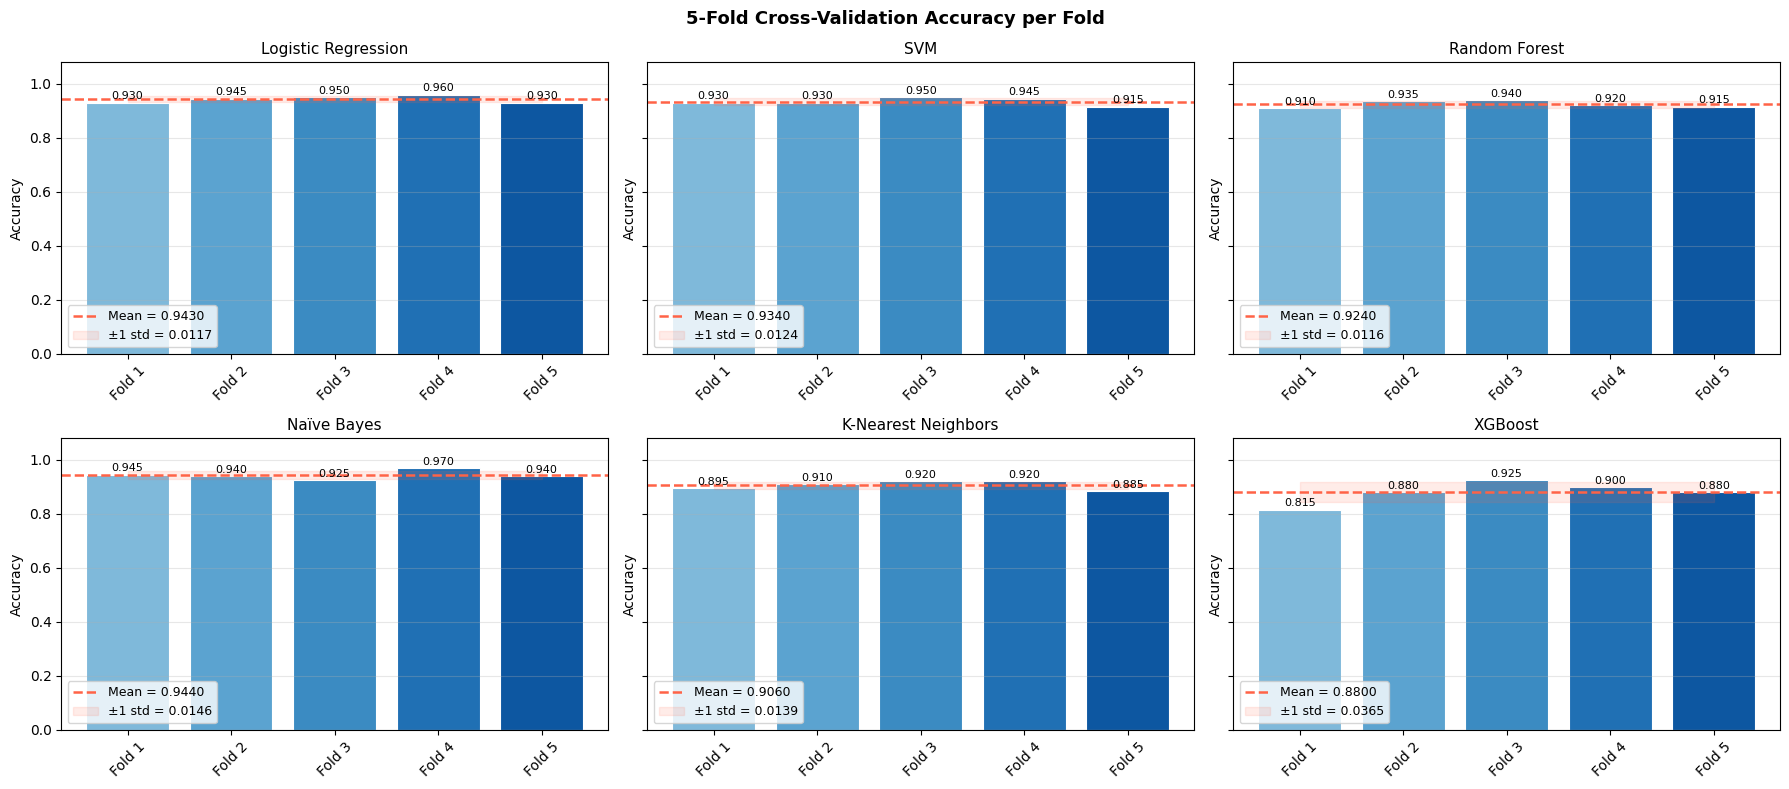

Saved: cv_accuracy_per_fold.png


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

le = LabelEncoder()
y_encoded = le.fit_transform(y)

kfold = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in [("Logistic Regression", lr), ("SVM", svm), ("Random Forest", rf), ("Naïve Bayes", nb), ("K-Nearest Neighbors", knn), ("XGBoost", xgb)]:
    scores = cross_val_score(model, X, y_encoded, cv=kfold, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name}")
    print(f"  Mean accuracy : {scores.mean():.4f}")
    print(f"  Std deviation : {scores.std():.4f}")
    print(f"  Per-fold      : {np.round(scores, 4)}")
    print()

# ── Per-fold accuracy bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
fig.suptitle(f"{CV_FOLDS}-Fold Cross-Validation Accuracy per Fold",
             fontsize=13, fontweight='bold')

fold_labels = [f"Fold {i+1}" for i in range(CV_FOLDS)]
colors = plt.cm.Blues(np.linspace(0.45, 0.85, CV_FOLDS))

for ax, (name, scores) in zip(axes.flatten(), cv_results.items()):
    bars = ax.bar(fold_labels, scores, color=colors, edgecolor='white', linewidth=0.8)
    ax.axhline(scores.mean(), color='tomato', linewidth=1.8,
               linestyle='--', label=f'Mean = {scores.mean():.4f}')
    ax.fill_between(range(CV_FOLDS),
                    scores.mean() - scores.std(),
                    scores.mean() + scores.std(),
                    alpha=0.12, color='tomato', label=f'±1 std = {scores.std():.4f}')
    # Annotate bars
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{score:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(name, fontsize=11)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel('Accuracy')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cv_accuracy_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cv_accuracy_per_fold.png')


## Confusion Matrices
Each cell shows how many test partitions were assigned to each predicted genre.
Off-diagonal cells are misclassifications — useful for spotting which genres
get confused with each other.

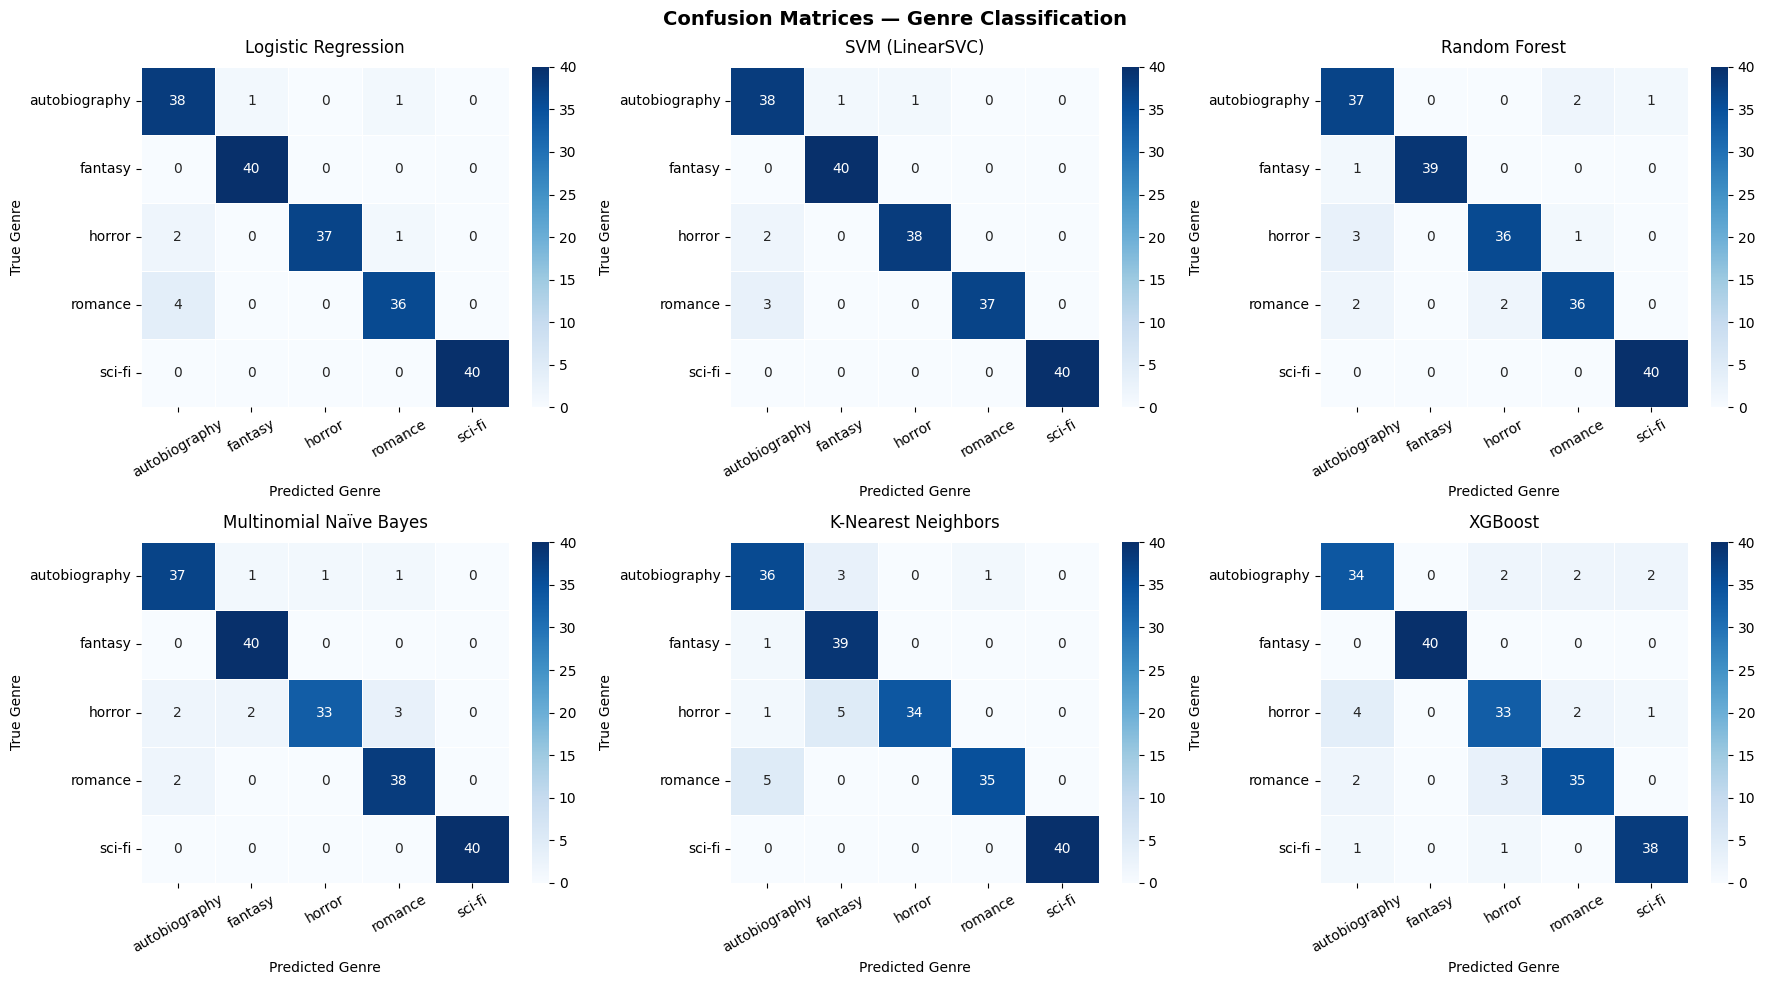

Saved: confusion_matrices.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Confusion Matrices — Genre Classification", fontsize=14, fontweight='bold')

for ax, y_pred, title in [
    (axes[0, 0], y_pred_lr,  "Logistic Regression"),
    (axes[0, 1], y_pred_svm, "SVM (LinearSVC)"),
    (axes[0, 2], y_pred_rf,  "Random Forest"),
    (axes[1, 0], y_pred_nb,  "Multinomial Naïve Bayes"),
    (axes[1, 1], y_pred_knn, "K-Nearest Neighbors"),
    (axes[1, 2], y_pred_xgb, "XGBoost"),
]:
    if not isinstance(y_pred[0], str):
        y_pred_decoded = le.inverse_transform(y_pred)
    else:
        y_pred_decoded = y_pred
        
    cm = confusion_matrix(y_test, y_pred_decoded, labels=GENRES)
    sns.heatmap(
        cm,
        annot        = True,
        fmt          = 'd',
        cmap         = 'Blues',
        xticklabels  = GENRES,
        yticklabels  = GENRES,
        linewidths   = 0.5,
        ax           = ax,
    )
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel("Predicted Genre", fontsize=10)
    ax.set_ylabel("True Genre", fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")



## Error Analysis
Inspect the actual misclassified partitions to understand *why* genres get confused.

In [14]:
def error_analysis(model_name, y_pred):
    """Print misclassified partitions with their true and predicted genres."""
    # Align predictions back to the original partition rows used in the test split
    test_indices = partitions.index[
        partitions.index.isin(
            partitions.iloc[
                list(range(len(partitions)))
            ].index
        )
    ]

    # Rebuild a results frame from the test split
    _, X_test_raw, _, y_test_raw = train_test_split(
        partitions['text'].values, partitions['genre'].values,
        test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=partitions['genre'].values
    )

    errors = pd.DataFrame({
        'text':      X_test_raw,
        'true':      y_test_raw,
        'predicted': y_pred,
    })
    errors = errors[errors['true'] != errors['predicted']]

    print(f"\n{'='*60}")
    print(f"  {model_name} — {len(errors)} misclassified partitions")
    print(f"{'='*60}")
    print(errors.groupby(['true','predicted']).size().rename('count').to_string())
    print(f"\n--- Sample misclassifications (up to 3 per pair) ---")
    for (true, pred), group in errors.groupby(['true','predicted']):
        for _, row in group.head(3).iterrows():
            print(f"\n[True: {true}] → [Predicted: {pred}]")
            print(f"  {row['text'][:200]}...")

error_analysis("Logistic Regression", y_pred_lr)
error_analysis("SVM", y_pred_svm)
error_analysis("Random Forest", y_pred_rf)
error_analysis("Multinomial Naïve Bayes", y_pred_nb)
error_analysis("K-Nearest Neighbors", y_pred_knn)
error_analysis("XGBoost", y_pred_xgb)



  Logistic Regression — 9 misclassified partitions
true           predicted    
autobiography  fantasy          1
               romance          1
horror         autobiography    2
               romance          1
romance        autobiography    4

--- Sample misclassifications (up to 3 per pair) ---

[True: autobiography] → [Predicted: fantasy]
  and prudent in the conduct of life; and little or no notice was ever taken of what related to the victuals on the table, whether it was well or ill dressed, in or out of season, of good or bad flavor,...

[True: autobiography] → [Predicted: romance]
  a friendly concern for thy welfare, to have no acquaintance with them." As I seem'd at first not to think so ill of them as she did, she mentioned some things she had observ'd and heard that had escap...

[True: horror] → [Predicted: autobiography]
  a fellow professor, would lecture upon chemistry the alternate days that he omitted. I returned home not disappointed, for I have said that I ha

## Save Trained Models
Serialises both models and the vectorizer so they can be loaded without re-training.

In [15]:
joblib.dump(lr,         'model_logistic_regression.pkl')
joblib.dump(svm,        'model_svm.pkl')
joblib.dump(rf,         'model_random_forest.pkl')
joblib.dump(nb,         'model_naive_bayes.pkl')
joblib.dump(knn,        'model_knn.pkl')
joblib.dump(xgb,        'model_xgboost.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
print("Saved: model_logistic_regression.pkl")
print("Saved: model_svm.pkl")
print("Saved: model_random_forest.pkl")
print("Saved: model_naive_bayes.pkl")
print("Saved: model_knn.pkl")
print("Saved: model_xgboost.pkl")
print("Saved: vectorizer.pkl")

Saved: model_logistic_regression.pkl
Saved: model_svm.pkl
Saved: model_random_forest.pkl
Saved: model_naive_bayes.pkl
Saved: model_knn.pkl
Saved: model_xgboost.pkl
Saved: vectorizer.pkl


## Quick Predict on New Text
Load the saved models and classify an arbitrary passage.

In [16]:
# Load saved artefacts
vec  = joblib.load('vectorizer.pkl')
lr2  = joblib.load('model_logistic_regression.pkl')
svm2 = joblib.load('model_svm.pkl')
rf2  = joblib.load('model_random_forest.pkl')
nb2  = joblib.load('model_naive_bayes.pkl')
knn2 = joblib.load('model_knn.pkl')
xgb2 = joblib.load('model_xgboost.pkl')

sample_text = [
    "The robot spaceship launched into the dark void of deep space as the crew "
    "prepared for their mission to the distant star system far beyond the galaxy."
]

X_sample = vec.transform(sample_text)
print(f"LR  prediction : {lr2.predict(X_sample)[0]}")
print(f"SVM prediction : {svm2.predict(X_sample)[0]}")
print(f"RF  prediction : {rf2.predict(X_sample)[0]}")
print(f"NB  prediction : {nb2.predict(X_sample)[0]}")
print(f"KNN prediction : {knn2.predict(X_sample)[0]}")
print(f"XGB prediction : {GENRES[xgb2.predict(X_sample)[0]]}")

# LR, RF, NB, and XGB give probabilities per genre
print(f"\n--- LR class probabilities ---")
probs_lr = pd.Series(lr2.predict_proba(X_sample)[0], index=lr2.classes_)
print(probs_lr.sort_values(ascending=False).to_string())

print(f"\n--- RF class probabilities ---")
probs_rf = pd.Series(rf2.predict_proba(X_sample)[0], index=rf2.classes_)
print(probs_rf.sort_values(ascending=False).to_string())

print(f"\n--- NB class probabilities ---")
probs_nb = pd.Series(nb2.predict_proba(X_sample)[0], index=nb2.classes_)
print(probs_nb.sort_values(ascending=False).to_string())

print(f"\n--- KNN class probabilities ---")
probs_knn = pd.Series(knn2.predict_proba(X_sample)[0], index=knn2.classes_)
print(probs_knn.sort_values(ascending=False).to_string())

print(f"\n--- XGB class probabilities ---")
probs_xgb = pd.Series(xgb2.predict_proba(X_sample)[0], index=GENRES)
print(probs_xgb.sort_values(ascending=False).to_string())



LR  prediction : sci-fi
SVM prediction : sci-fi
RF  prediction : sci-fi
NB  prediction : sci-fi
KNN prediction : sci-fi
XGB prediction : horror

--- LR class probabilities ---
sci-fi           0.470162
horror           0.189683
autobiography    0.150268
romance          0.105949
fantasy          0.083938

--- RF class probabilities ---
sci-fi           0.415
horror           0.360
autobiography    0.220
romance          0.005
fantasy          0.000

--- NB class probabilities ---
sci-fi           0.748652
horror           0.072929
autobiography    0.062220
romance          0.058907
fantasy          0.057292

--- KNN class probabilities ---
sci-fi           1.0
autobiography    0.0
fantasy          0.0
horror           0.0
romance          0.0

--- XGB class probabilities ---
horror           0.487215
autobiography    0.265312
sci-fi           0.203507
romance          0.034555
fantasy          0.009411
